In [42]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [43]:
class QuadState(TypedDict):
    a:int
    b:int
    c:int

    equation: str
    descriminant: float
    result: str

In [44]:
def show_equation(state: QuadState):
    equation = f'{state["a"]}x2{state["b"]}x{state["c"]}'
    return {'equation' : equation}


def calculate_descriminant(state: QuadState):
    descriminant = state["b"]**2 - (4*(state["a"])*state["c"])
    return {'descriminant': descriminant}

def real_roots(state: QuadState):
    root1 = (-state["b"] + state["descriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["descriminant"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'
    return {'result': result}

def repeated_roots(state: QuadState):
    root = (-state["b"])/(2*state["a"])
    result = f'The roots are real and equal to {root}'

    return {'result' : result}

def no_real_roots(state: QuadState):
    result = f'No real roots'
    return {'result' : result}

def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:
    if state['descriminant'] > 0:
        return "real_roots"
    elif state['descriminant'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"



In [45]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_descriminant', calculate_descriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_descriminant')

graph.add_conditional_edges('calculate_descriminant', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)



In [46]:
workflow = graph.compile()

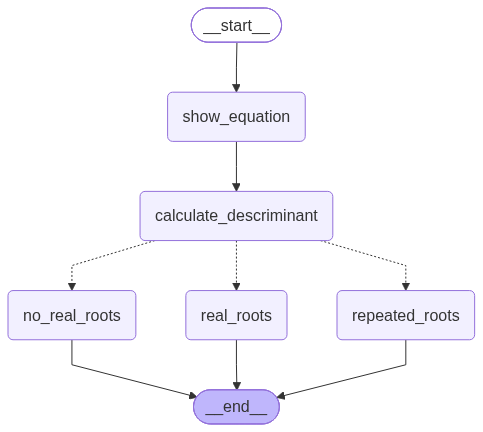

In [47]:
workflow

In [48]:
initial_state = {
    'a': 2, 
    'b': 4,
    'c': 2
}

workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x24x2',
 'descriminant': 0,
 'result': 'The roots are real and equal to -1.0'}